# MaCOM SST 订正 — 推理与可视化 Demo

加载已训练的模型，在全域高分辨率 MaCOM 数据上推理，
降采样到 GLO12 低分辨率网格后评估效果。

## 1. 环境设置与库导入

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from netCDF4 import Dataset as NCDataset, num2date

from config import experiment_params, data_params, model_params
from models.baseline.CResU_Net import CRUNet
from dataset_macom import MaCOMPatchDataset, _extract_datetime_from_filename
from data.glo12_reader import GLO12Reader
from downsample import build_downsample_grid, downsample_to_glo12, downsample_mask_nearest

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

macom_cfg = data_params['macom']
model_cfg = model_params['CResU_Net']

Device: cuda


## 2. 加载最佳模型

In [2]:
model = CRUNet(
    in_channels=model_cfg['core']['in_channels'],
    out_channels=model_cfg['core']['out_channels'],
    selected_dim=0, device=device,
    base_channels=model_cfg['core'].get('base_channels', 64),
    dropout=model_cfg['core'].get('dropout', 0.0),
).to(device)

model_path = os.path.join(experiment_params['save_dir'], experiment_params['model_save_name'])
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f'模型加载完成: {model_path}')

模型加载完成: ./train_results_macom/best_model.pth


/tmp/ipykernel_1304354/2455196327.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


## 3. 准备数据（GLO12 + 测试集文件）

In [3]:
glo12 = GLO12Reader(macom_cfg['glo12_pattern'], tolerance_hours=macom_cfg['time_tolerance_hours'])
print(f'GLO12: {glo12.shape}, lat=[{glo12.lat[0]:.2f},{glo12.lat[-1]:.2f}], lon=[{glo12.lon[0]:.2f},{glo12.lon[-1]:.2f}]')

# 选一个验证集文件做演示（取第 46 个文件，在 53 个文件中约在 val 区间）
import glob
all_files = sorted(glob.glob(macom_cfg['forecast_pattern']))
n_val_start = -1  # 训练集约 43 个文件
demo_file = all_files[n_val_start]
print(f'文件总数: {len(all_files)}, 选择索引: {n_val_start}')
print(f'示例文件: {os.path.basename(demo_file)}')

GLO12: (1536, 25, 26), lat=[30.00,32.00], lon=[120.58,122.67]
文件总数: 53, 选择索引: -1
示例文件: MaCOM_swt_SH_001h_20260526_168.nc


## 4. 全图推理 + Downsample

In [4]:
# === 全图推理 + Downsample（无 patch 切分，无拼接痕迹） ===

with NCDataset(demo_file, "r") as ds:
    var = ds.variables["t"]
    src_h, src_w = var.shape[2], var.shape[3]
    src_lat = ds.variables["lat"][:]
    src_lon = ds.variables["lon"][:]
    tvar = ds.variables["time"]
    raw_time = tvar[:]
    time_units = tvar.units if "since" in tvar.units else "seconds since 1949-10-01 00:00:00"
    file_times = list(num2date(raw_time, units=time_units, calendar=getattr(tvar, "calendar", "standard")))
    data = ds.variables["t"][:, 0, :, :]
    sst = np.array(data, dtype=np.float32)
    if np.ma.is_masked(data):
        sst[data.mask] = np.nan

print(f"MaCOM 网格: {src_h}x{src_w}, time steps: {sst.shape[0]}")

glo12_indices, glo12_valid = glo12.nearest_time_indices(file_times, macom_cfg["time_tolerance_hours"])
print(f"GLO12 匹配: {glo12_valid.sum()}/{len(glo12_valid)}")

glo12_h, glo12_w = len(glo12.lat), len(glo12.lon)
glo12_sst = np.full((len(glo12_indices), glo12_h, glo12_w), np.nan, dtype=np.float32)
if np.any(glo12_valid):
    glo12_sst[glo12_valid] = glo12.get_sst(glo12_indices[glo12_valid])

TARGET_STEPS = 168
real_steps = min(sst.shape[0], TARGET_STEPS)
sst_crop = sst[:real_steps]
glo12_sst = glo12_sst[:real_steps]
glo12_valid = glo12_valid[:real_steps]

# Pad 宽度到 16 的倍数
pad_w = (16 - src_w % 16) % 16
padded_w = src_w + pad_w
if pad_w > 0:
    sst_crop = np.pad(sst_crop, ((0, 0), (0, 0), (0, pad_w)), mode="edge")

# 位置编码（与 dataset_macom.py 一致）
lat_2d = np.broadcast_to(src_lat[:, None], (src_h, src_w)).astype(np.float32)
lon_2d = np.broadcast_to(src_lon[None, :], (src_h, src_w)).astype(np.float32)
if pad_w > 0:
    lat_2d = np.pad(lat_2d, ((0, 0), (0, pad_w)), mode="edge")
    lon_2d = np.pad(lon_2d, ((0, 0), (0, pad_w)), mode="edge")
POS_SCALE = 1.0
lat_map = POS_SCALE * (2.0 * (lat_2d - lat_2d.min()) / (lat_2d.max() - lat_2d.min() + 1e-8) - 1.0)
lon_map = POS_SCALE * (2.0 * (lon_2d - lon_2d.min()) / (lon_2d.max() - lon_2d.min() + 1e-8) - 1.0)

land_mask = (~np.isnan(sst_crop)).any(axis=0).astype(np.float32)

if real_steps < TARGET_STEPS:
    pad_len = TARGET_STEPS - real_steps
    sst_crop = np.pad(sst_crop, ((0, pad_len), (0, 0), (0, 0)), mode="constant", constant_values=0.0)
    glo12_sst = np.pad(glo12_sst, ((0, pad_len), (0, 0), (0, 0)), mode="constant", constant_values=np.nan)
    glo12_valid = np.pad(glo12_valid, ((0, pad_len),), mode="constant", constant_values=False)

sst_input = np.nan_to_num(sst_crop, nan=0.0)

# 组装全图输入 (171, H, W_pad)
mask_ch = land_mask.reshape(1, src_h, padded_w)
lat_ch = lat_map.reshape(1, src_h, padded_w)
lon_ch = lon_map.reshape(1, src_h, padded_w)
x_np = np.concatenate([sst_input, mask_ch, lat_ch, lon_ch], axis=0)
x_tensor = torch.from_numpy(x_np).float().unsqueeze(0).to(device)

print(f"全图输入: {x_tensor.shape} — 单次前向推理，无拼接")

with torch.no_grad():
    with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pred_bias = model(x_tensor)

corrected = x_tensor[:, :168] - pred_bias
fc_full = x_tensor[0, :TARGET_STEPS, :, :src_w].cpu().float().numpy()
corr_full = corrected[0, :, :, :src_w].cpu().float().numpy()

print(f"推理完成: forecast {fc_full.shape}, corrected {corr_full.shape}")

# Downsample 到 GLO12（用原始宽度）
grid = build_downsample_grid(
    src_lat, src_lon, src_h, src_w,
    glo12.lat, glo12.lon, glo12_h, glo12_w,
    y_offset=0, x_offset=0, patch_h=src_h, patch_w=src_w,
).to(device)

grid_mask = (
    (grid[0, :, :, 0] >= -1.0) & (grid[0, :, :, 0] <= 1.0) &
    (grid[0, :, :, 1] >= -1.0) & (grid[0, :, :, 1] <= 1.0)
).cpu().numpy().astype(np.float32)

def remove_isolated(m2d, min_neighbors=3):
    m2d = (m2d > 0).astype(np.float32)
    p = np.pad(m2d, 1, mode="constant", constant_values=0)
    n = p[:-2,:-2]+p[:-2,1:-1]+p[:-2,2:]+p[1:-1,:-2]+p[1:-1,1:-1]+p[1:-1,2:]+p[2:,:-2]+p[2:,1:-1]+p[2:,2:]
    return (m2d > 0) & (n >= min_neighbors)

src_ocean = (~np.isnan(sst[0])).astype(np.float32)
mask_hr = torch.from_numpy(src_ocean).float().to(device)

fc_lowres = downsample_to_glo12(torch.from_numpy(fc_full).unsqueeze(0).to(device), grid, mask=mask_hr)[0].cpu().numpy()
corr_lowres = downsample_to_glo12(torch.from_numpy(corr_full).unsqueeze(0).to(device), grid, mask=mask_hr)[0].cpu().numpy()
target = glo12_sst[:TARGET_STEPS]

glo12_ocean = downsample_mask_nearest(src_ocean, src_lat, src_lon, glo12.lat, glo12.lon,
                                       y_offset=0, x_offset=0, patch_h=src_h, patch_w=src_w)
glo12_land = np.any(~np.isnan(glo12_sst), axis=0).astype(np.float32)
time_mask = glo12_valid[:TARGET_STEPS].astype(np.float32)
mask_lowres = time_mask[:, None, None] * glo12_land[None, :, :] * glo12_ocean[None, :, :] * grid_mask[None, :, :]
spatial_mask = (mask_lowres.max(axis=0) > 0).astype(np.float32)
spatial_mask = remove_isolated(spatial_mask, min_neighbors=3).astype(np.float32)
mask_lowres = mask_lowres * spatial_mask[None, :, :]
n_steps = real_steps

print(f"Downsample 完成: {fc_lowres.shape}")

MaCOM 网格: 1168x1000, time steps: 156
GLO12 匹配: 156/156
全图输入: torch.Size([1, 171, 1168, 1008]) — 单次前向推理，无拼接
推理完成: forecast (168, 1168, 1000), corrected (168, 1168, 1000)
Downsample 完成: (168, 25, 26)


In [5]:
# 检查海洋区域（取图中真正是海的位置）
ocean_mask_local = ~np.isnan(sst[0])
if ocean_mask_local.any():
    ocean_ys, ocean_xs = np.where(ocean_mask_local)
    y_mid = ocean_ys[len(ocean_ys)//2]
    x_mid = ocean_xs[len(ocean_xs)//2]
    t_check = 0
    print(f'海洋区域 ({y_mid}:{y_mid+5}, {x_mid}:{x_mid+5}) t={t_check}h:')
    print('Forecast  SST:', fc_full[t_check, y_mid:y_mid+5, x_mid:x_mid+5])
    print('Corrected SST:', corr_full[t_check, y_mid:y_mid+5, x_mid:x_mid+5])
    f_mean = np.nanmean(fc_full[t_check, ocean_mask_local])
    c_mean = np.nanmean(corr_full[t_check, ocean_mask_local])
    print(f'全图海洋均值: Forecast={f_mean:.3f}°C, Corrected={c_mean:.3f}°C, 差值={f_mean-c_mean:.3f}°C')
else:
    print('未找到海洋像素，请检查数据')

海洋区域 (454:459, 736:741) t=0h:
Forecast  SST: [[21.453493 21.448206 21.442749 21.437092 21.431236]
 [21.456583 21.45134  21.44597  21.44044  21.434729]
 [21.45992  21.45464  21.449295 21.443832 21.438217]
 [21.463676 21.458256 21.452848 21.447382 21.441816]
 [21.46805  21.462378 21.4568   21.451237 21.445631]]
Corrected SST: [[22.544313 22.53219  22.520874 22.50838  22.49569 ]
 [22.55131  22.53923  22.527025 22.515635 22.503088]
 [22.558554 22.546436 22.534256 22.521957 22.510483]
 [22.566216 22.553959 22.541716 22.529413 22.517012]
 [22.574495 22.561987 22.549574 22.537174 22.524733]]
全图海洋均值: Forecast=21.026°C, Corrected=22.216°C, 差值=-1.190°C


## 5. 高分辨率可视化：Forecast / Corrected / GLO12 Target / Bias

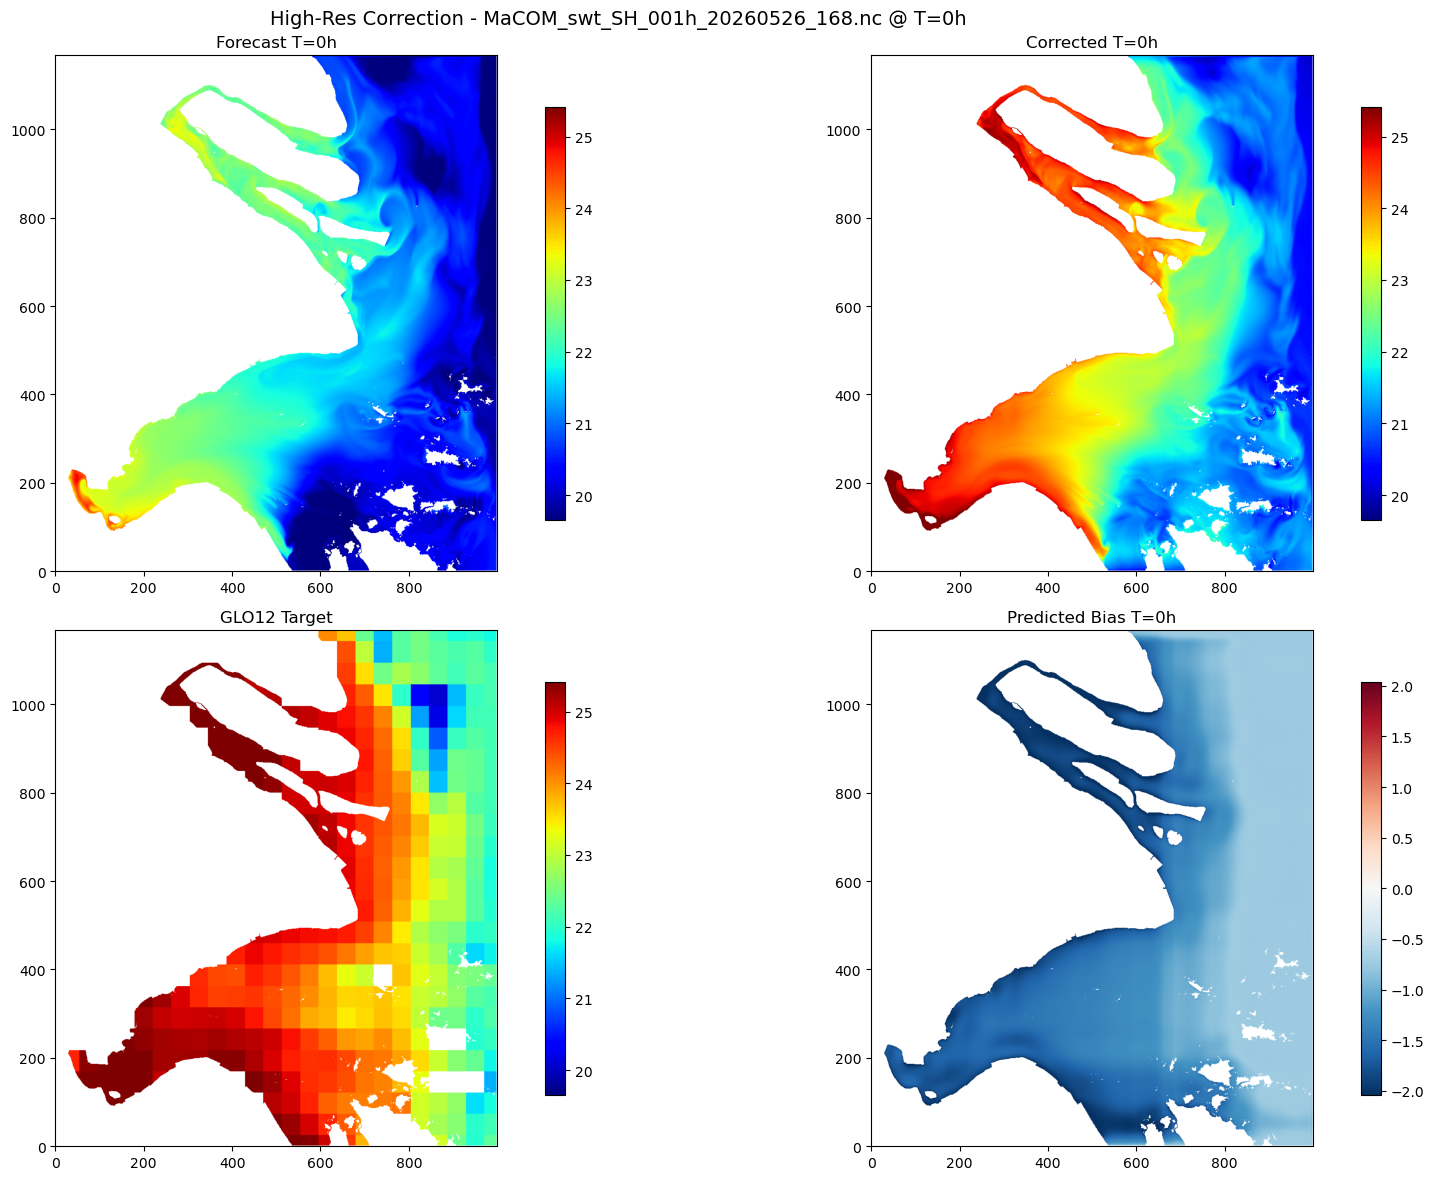

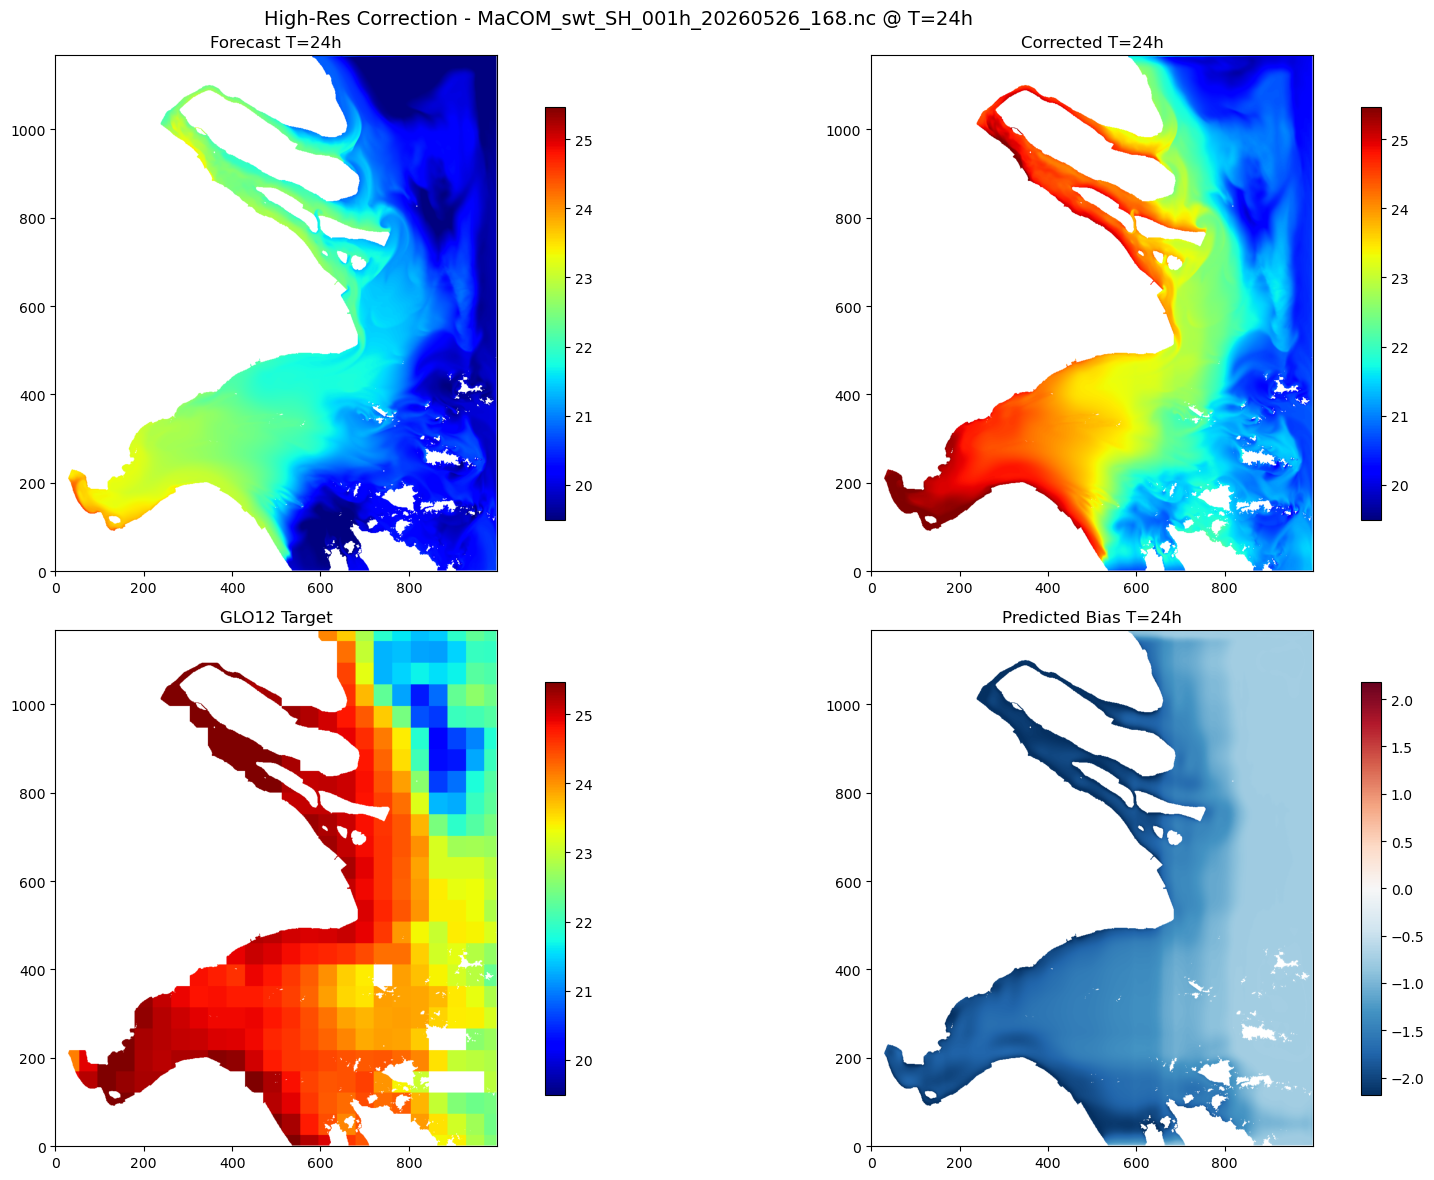

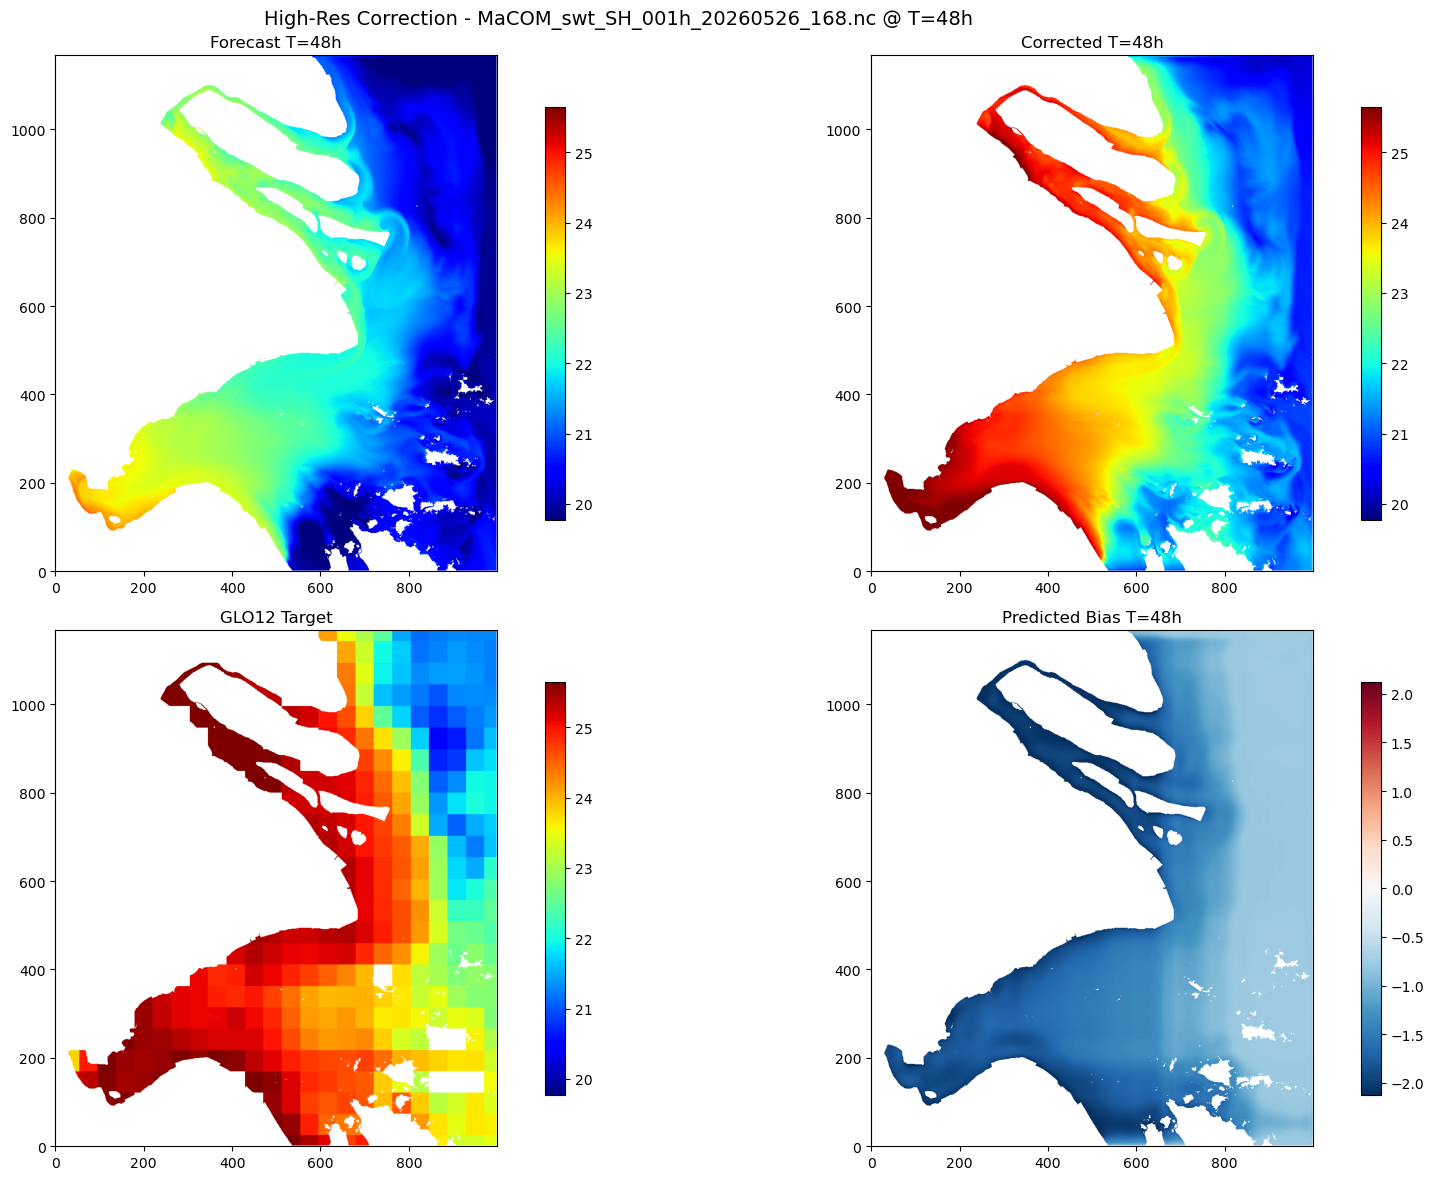

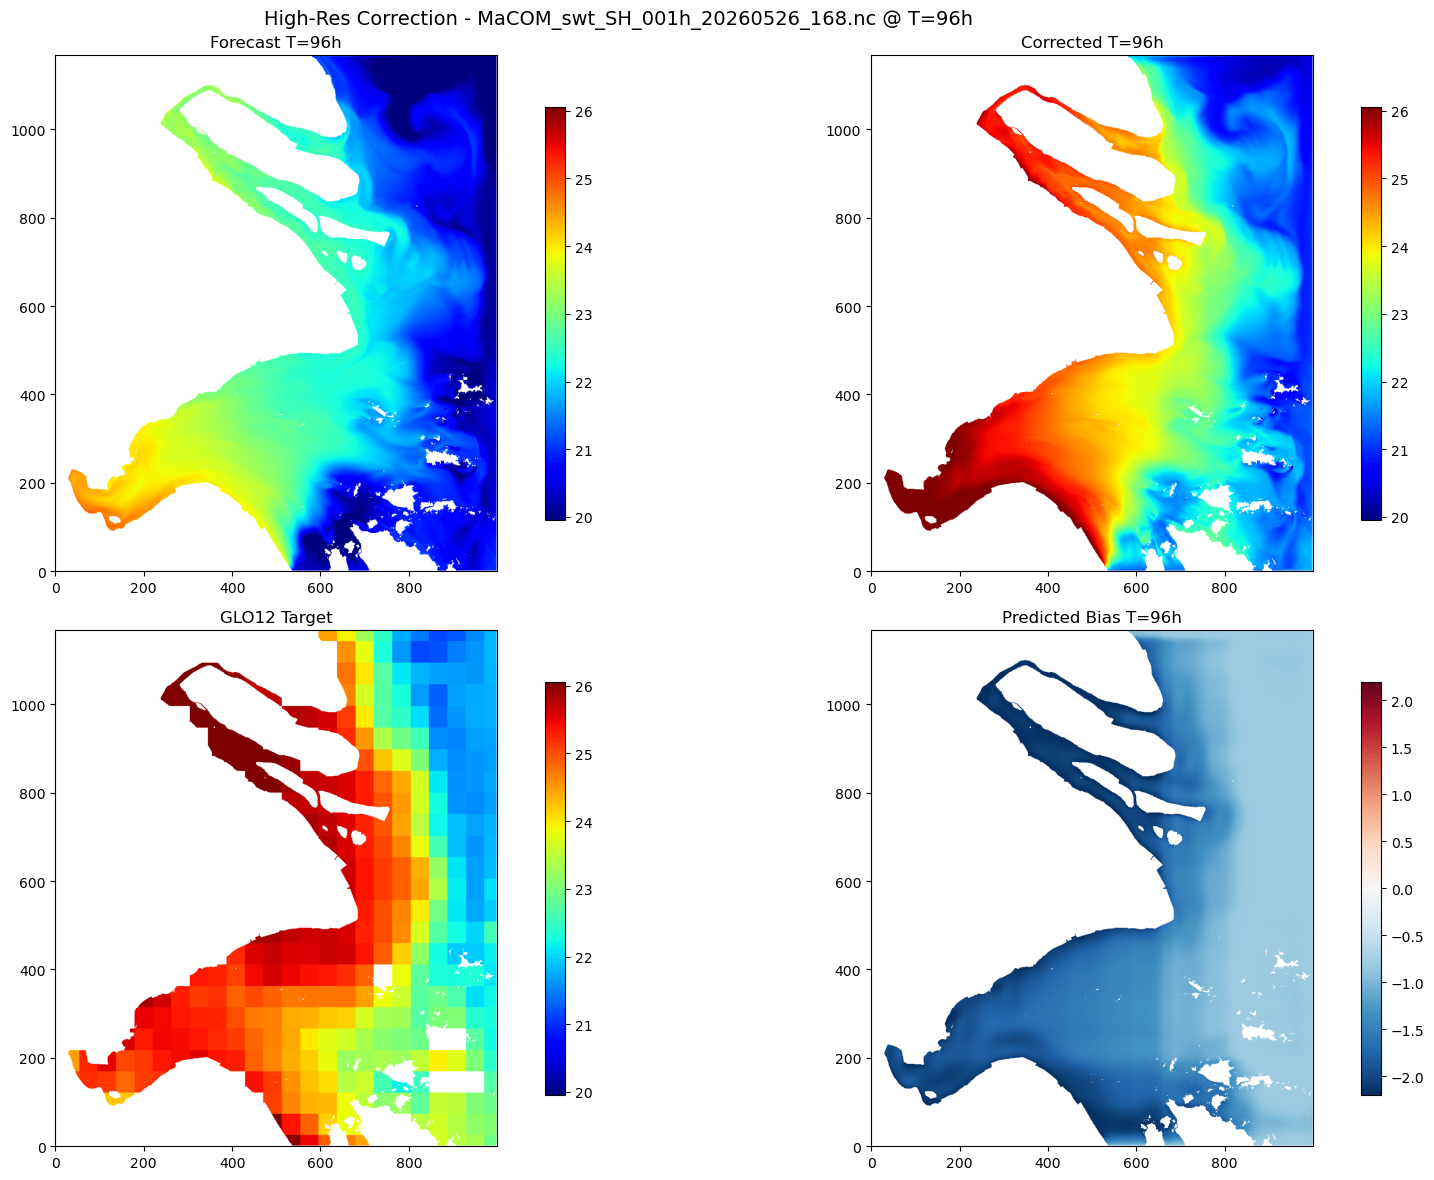

In [6]:
import torch.nn.functional as F

plot_steps = [0, 24, 48, 96, 167]
plot_steps = [t for t in plot_steps if t < n_steps]

highres_land = np.isnan(sst[0])

# 将 GLO12 按坐标映射到高分辨率网格
glo12_lat_step = (glo12.lat[-1] - glo12.lat[0]) / (glo12_h - 1)
glo12_lon_step = (glo12.lon[-1] - glo12.lon[0]) / (glo12_w - 1)
glo12_y = (src_lat - glo12.lat[0]) / glo12_lat_step
glo12_x = (src_lon - glo12.lon[0]) / glo12_lon_step
norm_y = 2.0 * glo12_y / (glo12_h - 1) - 1.0
norm_x = 2.0 * glo12_x / (glo12_w - 1) - 1.0
grid_gx, grid_gy = np.meshgrid(norm_x, norm_y)
grid_g = np.stack([grid_gx, grid_gy], axis=-1)
grid_g = torch.from_numpy(grid_g).float().unsqueeze(0).to(device)
glo12_tensor = torch.from_numpy(target).float().unsqueeze(0).to(device)
glo12_hr = F.grid_sample(glo12_tensor, grid_g, mode='nearest', align_corners=True)[0].cpu().numpy()

for t in plot_steps:
    fc_t = fc_full[t].copy()
    corr_t = corr_full[t].copy()
    bias_t = fc_t - corr_t
    tgt_hr_t = glo12_hr[t].copy()

    fc_t[highres_land] = np.nan
    corr_t[highres_land] = np.nan
    bias_t[highres_land] = np.nan
    tgt_hr_t[highres_land] = np.nan

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    all_vals = np.concatenate([
        fc_t[~np.isnan(fc_t)], corr_t[~np.isnan(corr_t)],
        tgt_hr_t[~np.isnan(tgt_hr_t)],
    ])
    vmin = np.percentile(all_vals, 2)
    vmax = np.percentile(all_vals, 98)
    cmap = plt.cm.jet; cmap.set_bad(color='white')

    im1 = axes[0, 0].imshow(fc_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[0, 0].set_title(f'Forecast T={t}h'); plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    im2 = axes[0, 1].imshow(corr_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[0, 1].set_title(f'Corrected T={t}h'); plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)

    im3 = axes[1, 0].imshow(tgt_hr_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[1, 0].set_title('GLO12 Target'); plt.colorbar(im3, ax=axes[1, 0], shrink=0.8)

    bias_valid = bias_t[~np.isnan(bias_t)]
    abs_max = max(np.percentile(np.abs(bias_valid), 98), 0.1)
    bias_cmap = plt.cm.RdBu_r; bias_cmap.set_bad(color='white')
    bias_norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    im4 = axes[1, 1].imshow(bias_t, cmap=bias_cmap, norm=bias_norm, origin='lower')
    axes[1, 1].set_title(f'Predicted Bias T={t}h'); plt.colorbar(im4, ax=axes[1, 1], shrink=0.8)

    plt.suptitle(f'High-Res Correction - {os.path.basename(demo_file)} @ T={t}h', fontsize=14)
    plt.tight_layout(); plt.show()

## 6. 低分辨率 GLO12 对比：Forecast vs Corrected vs Target

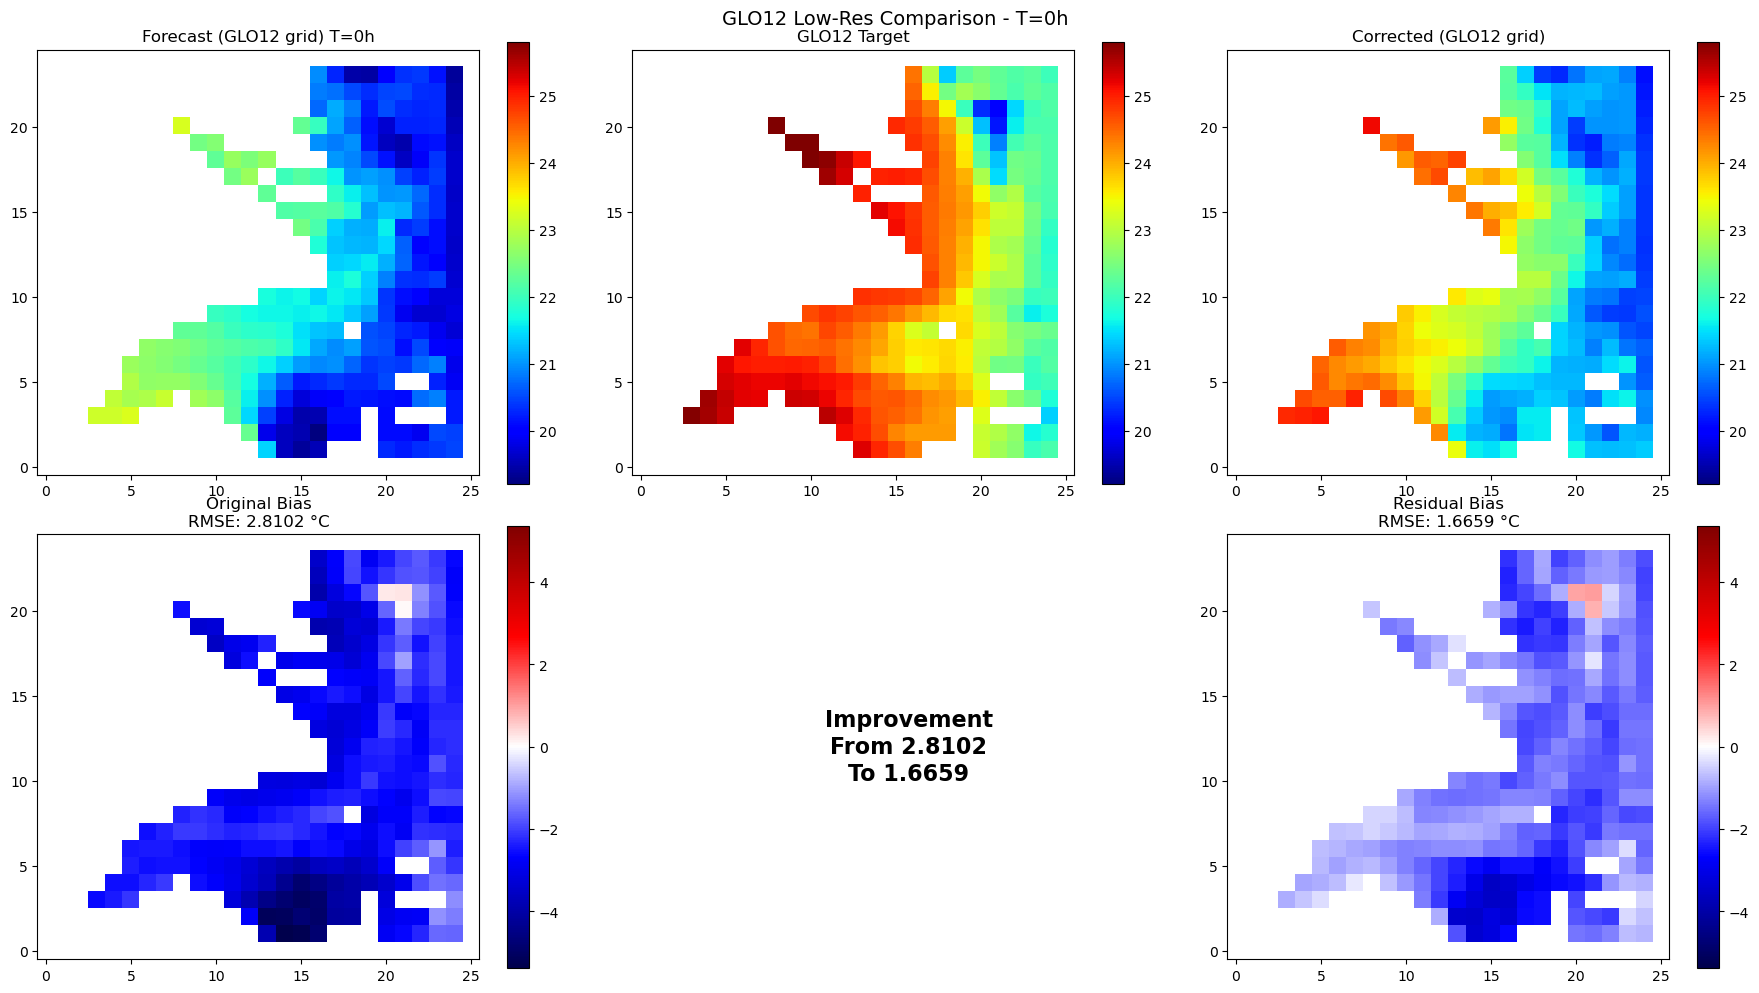

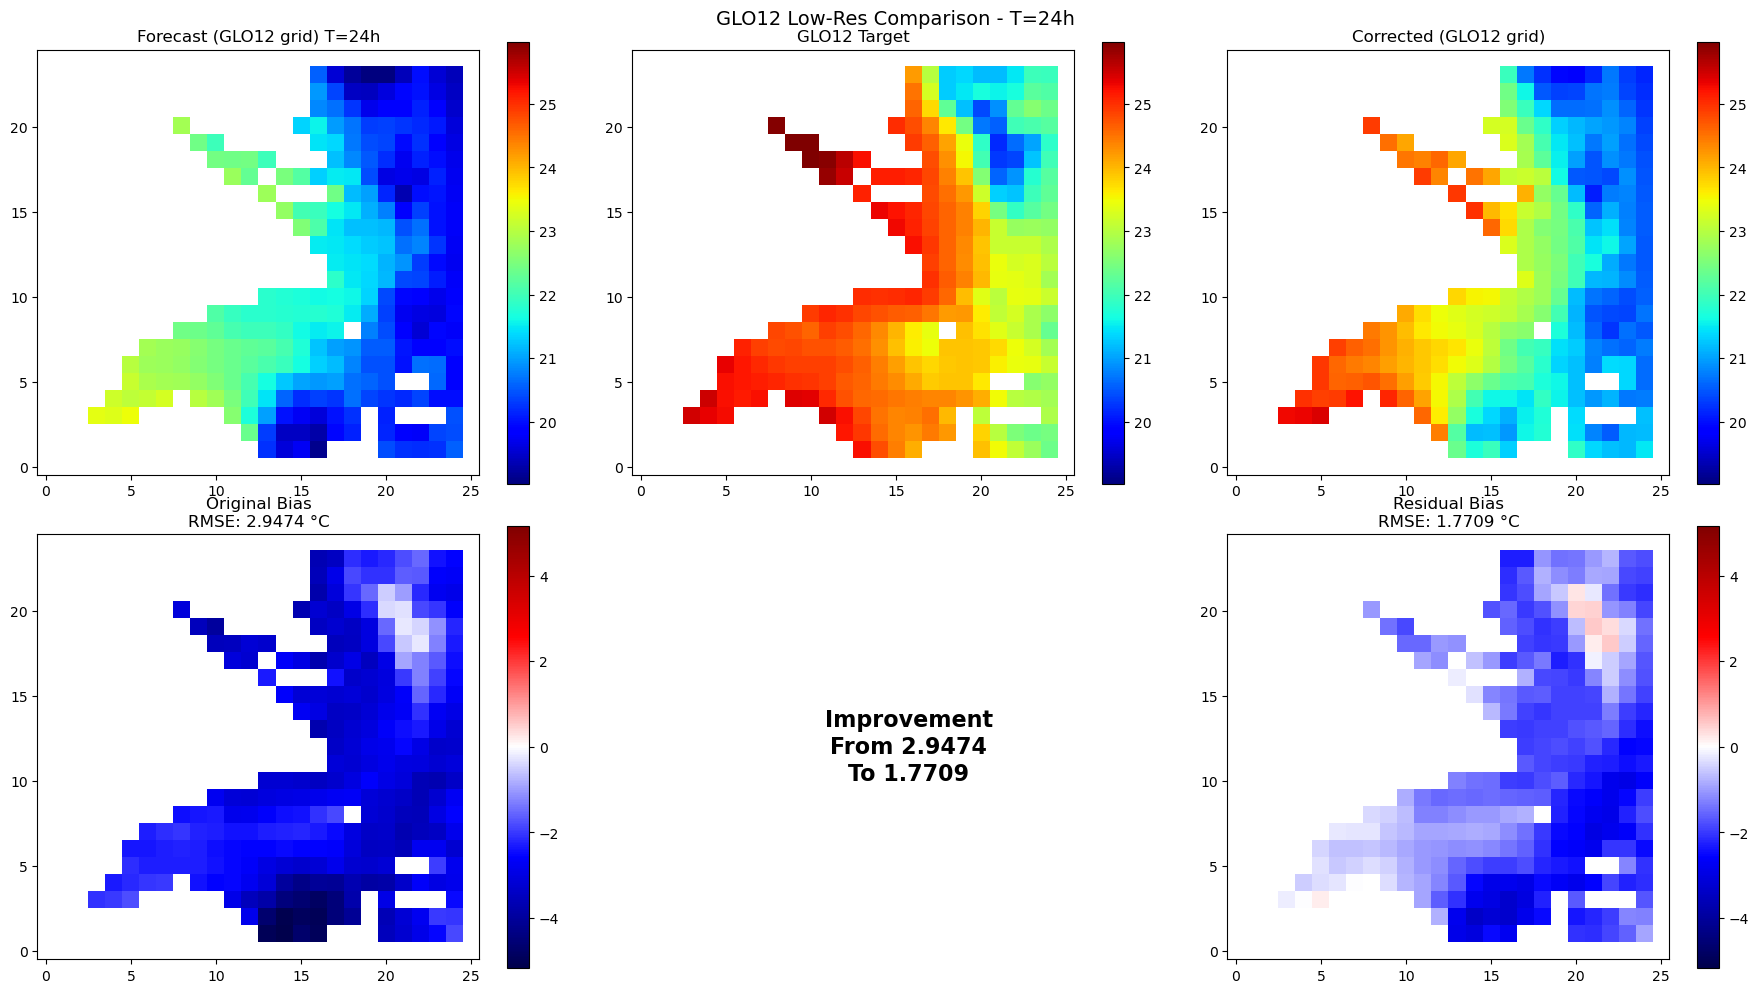

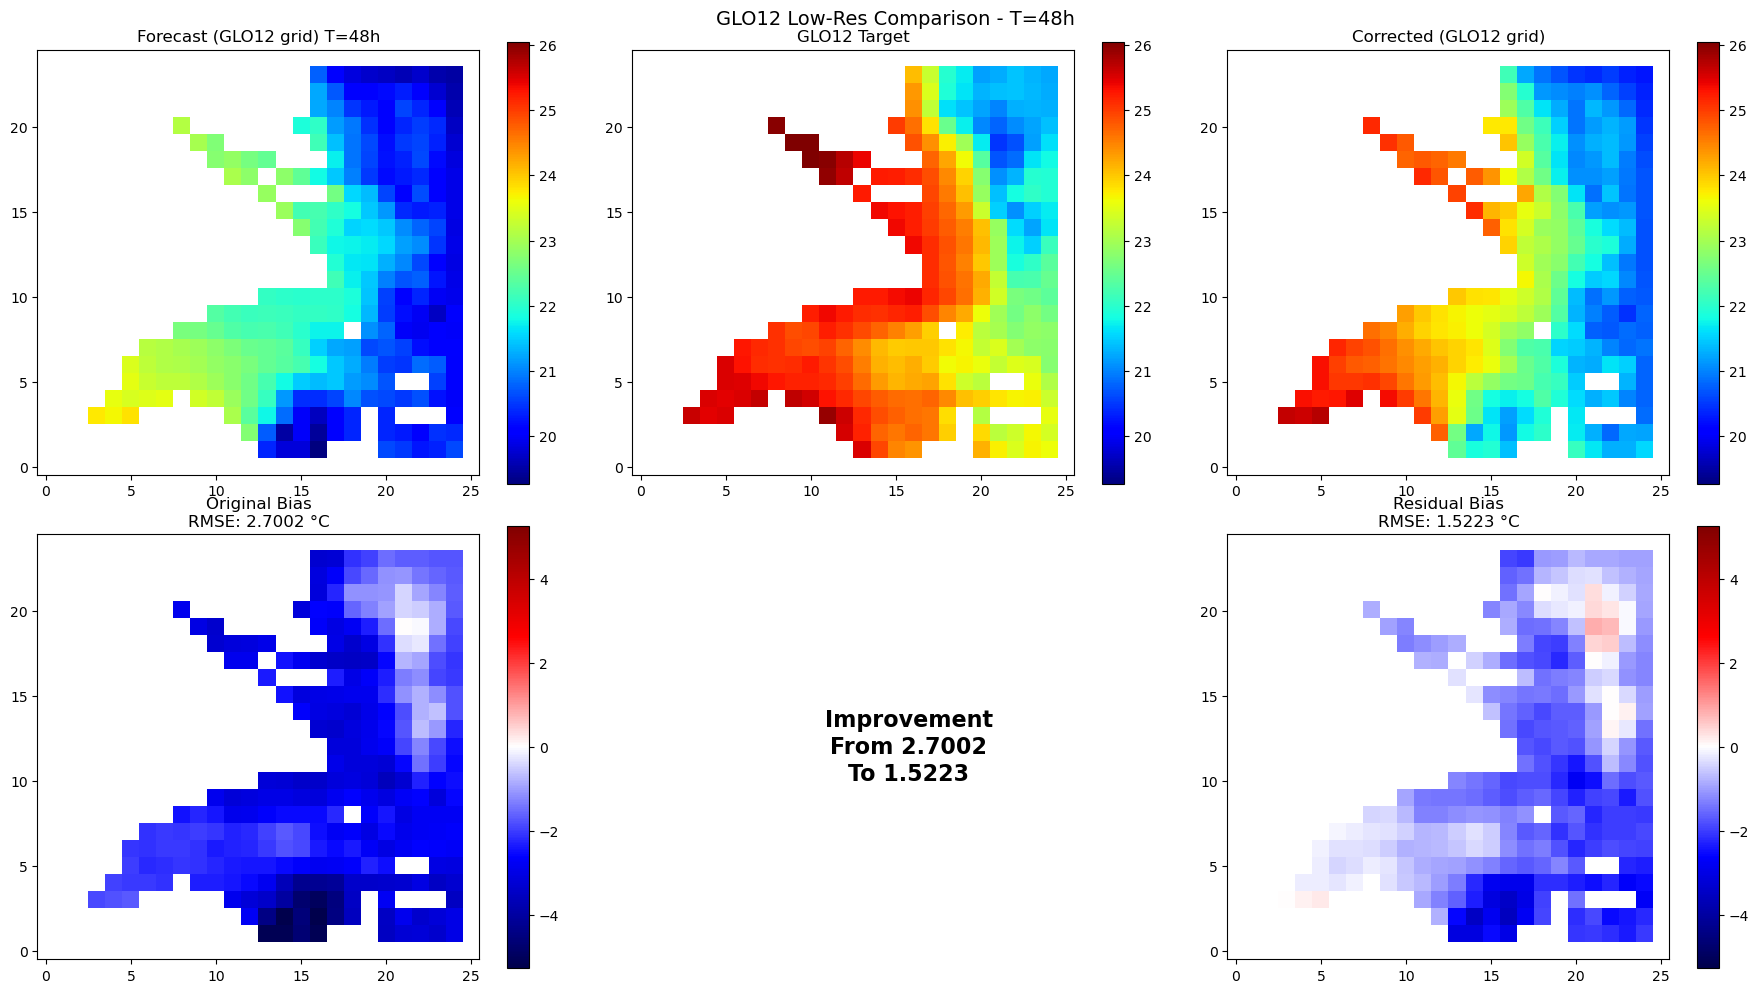

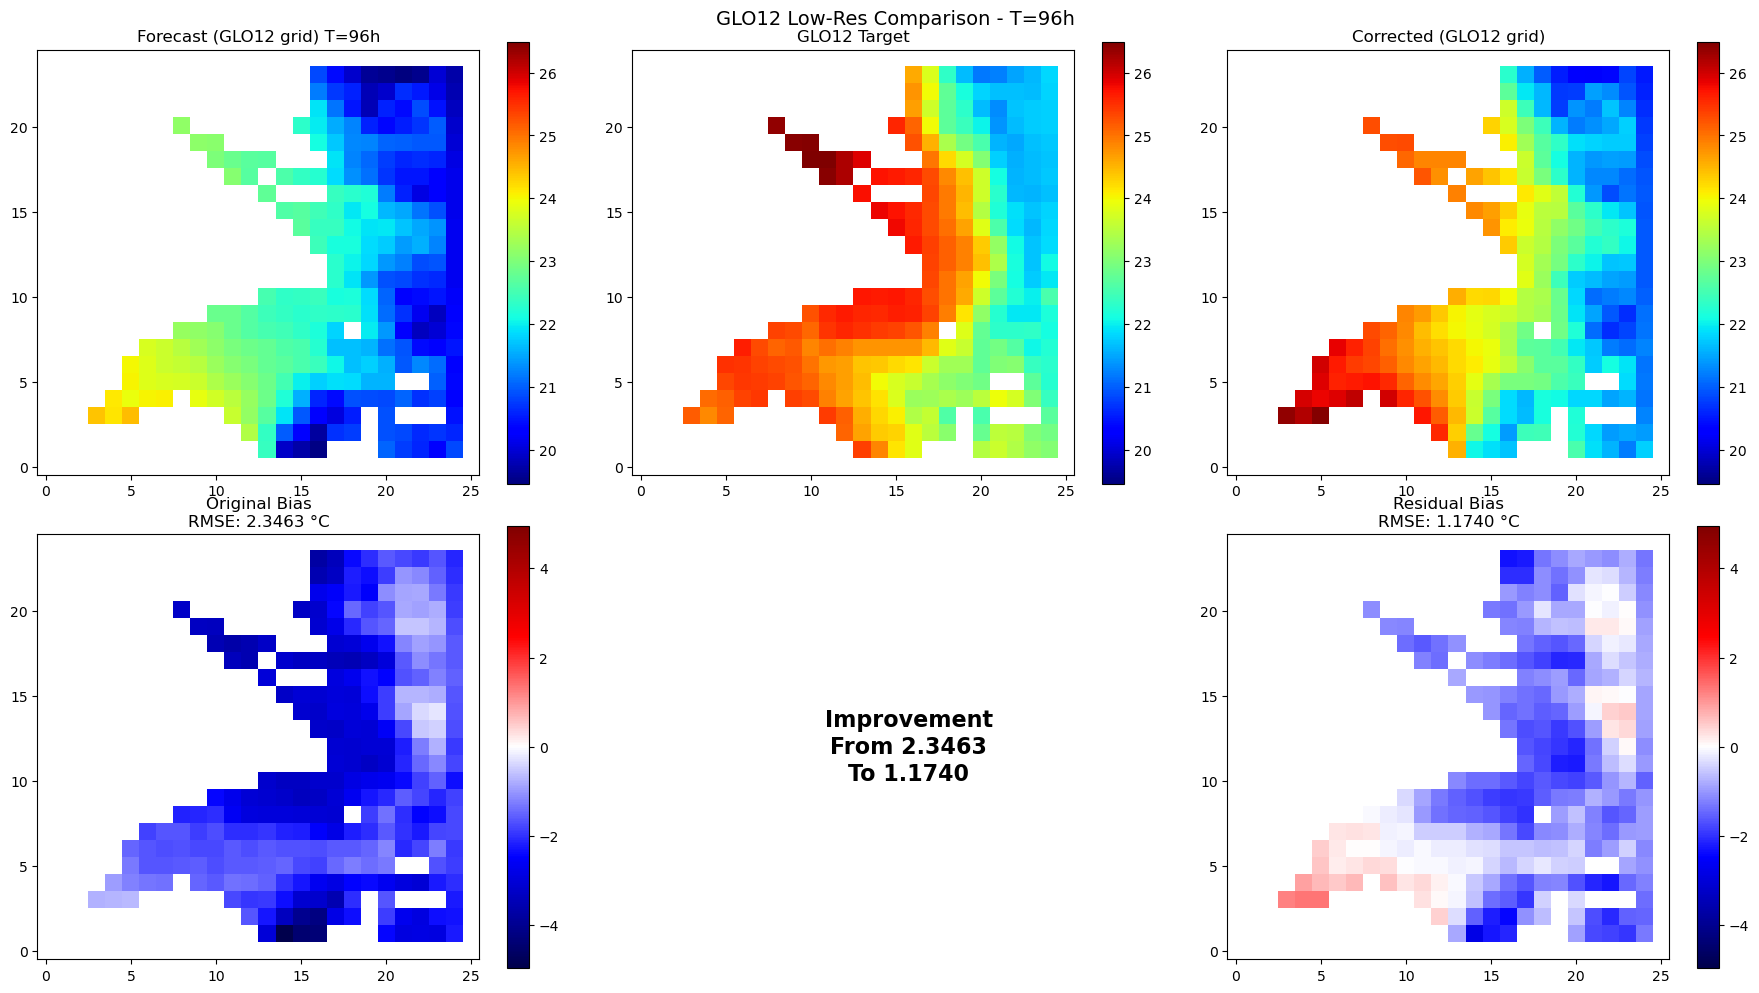

In [7]:
for t in plot_steps:
    fc_t = fc_lowres[t].copy()
    corr_t = corr_lowres[t].copy()
    tgt_t = target[t].copy()
    m = mask_lowres[t]

    fc_t[m == 0] = np.nan
    corr_t[m == 0] = np.nan
    tgt_t[m == 0] = np.nan

    orig_bias = fc_t - tgt_t
    resid_bias = corr_t - tgt_t
    orig_rmse = np.sqrt(np.nanmean(orig_bias ** 2))
    corr_rmse = np.sqrt(np.nanmean(resid_bias ** 2))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    vmin = np.nanmin([np.nanmin(fc_t), np.nanmin(tgt_t)])
    vmax = np.nanmax([np.nanmax(fc_t), np.nanmax(tgt_t)])
    cmap = plt.cm.jet
    cmap.set_bad(color='white')

    im1 = axes[0, 0].imshow(fc_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[0, 0].set_title(f'Forecast (GLO12 grid) T={t}h')
    plt.colorbar(im1, ax=axes[0, 0])

    im2 = axes[0, 1].imshow(tgt_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[0, 1].set_title('GLO12 Target')
    plt.colorbar(im2, ax=axes[0, 1])

    im3 = axes[0, 2].imshow(corr_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
    axes[0, 2].set_title('Corrected (GLO12 grid)')
    plt.colorbar(im3, ax=axes[0, 2])

    bias_cmap = plt.cm.seismic
    bias_cmap.set_bad(color='white')
    bias_max = max(np.nanmax(np.abs(orig_bias)), np.nanmax(np.abs(resid_bias)), 0.1)

    im4 = axes[1, 0].imshow(orig_bias, cmap=bias_cmap, vmin=-bias_max, vmax=bias_max, origin='lower')
    axes[1, 0].set_title(f'Original Bias\nRMSE: {orig_rmse:.4f} °C')
    plt.colorbar(im4, ax=axes[1, 0])

    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, f'Improvement\nFrom {orig_rmse:.4f}\nTo {corr_rmse:.4f}',
                    ha='center', va='center', fontsize=16, fontweight='bold')

    im5 = axes[1, 2].imshow(resid_bias, cmap=bias_cmap, vmin=-bias_max, vmax=bias_max, origin='lower')
    axes[1, 2].set_title(f'Residual Bias\nRMSE: {corr_rmse:.4f} °C')
    plt.colorbar(im5, ax=axes[1, 2])

    plt.suptitle(f'GLO12 Low-Res Comparison - T={t}h', fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. 全年误差统计（RMSE / MAE）

In [8]:
from predict_utils import compute_yearly_error_lowres

(rmse_fc, mae_fc), (rmse_corr, mae_corr) = compute_yearly_error_lowres(
    model_path=model_path,
    forecast_pattern=macom_cfg['forecast_pattern'],
    glo12_pattern=macom_cfg['glo12_pattern'],
    batch_size=1,
    num_workers=2,
)

print(f'\n===== 全年误差统计 (GLO12 低分辨率) =====')
print(f'Forecast  RMSE: {rmse_fc:.5f} °C | MAE: {mae_fc:.5f} °C')
print(f'Corrected RMSE: {rmse_corr:.5f} °C | MAE: {mae_corr:.5f} °C')
print(f'订正提升 (MAE): {(mae_fc - mae_corr):.5f} °C ({(1 - mae_corr/mae_fc)*100:.1f}%)')

MaCOMPatchDataset (全图模式): 53 files, grid=1168x1000->1168x1008
RMSE (Forecast): 9.63760 °C
MAE  (Forecast): 5.94464 °C
RMSE (Corrected): 9.49842 °C
MAE  (Corrected): 5.09466 °C

===== 全年误差统计 (GLO12 低分辨率) =====
Forecast  RMSE: 9.63760 °C | MAE: 5.94464 °C
Corrected RMSE: 9.49842 °C | MAE: 5.09466 °C
订正提升 (MAE): 0.84998 °C (14.3%)


## 8. 交互式样本探索器（可选）

In [9]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    import matplotlib.pyplot as plt

    t_slider = widgets.IntSlider(value=0, min=0, max=n_steps-1, step=1, description='Timestep:')
    res_toggle = widgets.ToggleButtons(options=['低分辨率 GLO12', '高分辨率全图'], description='视图:')
    out = widgets.Output()

    def show_timestep(*_):
        out.clear_output(wait=True)
        with out:
            t = t_slider.value
            use_highres = (res_toggle.value == '高分辨率全图')

            if use_highres:
                fc_t = fc_full[t].copy()
                corr_t = corr_full[t].copy()
                bias_t = fc_t - corr_t
                land = np.isnan(sst[0])
                fc_t[land] = np.nan; corr_t[land] = np.nan; bias_t[land] = np.nan

                fig, axes = plt.subplots(1, 3, figsize=(20, 5))
                vmin = np.nanpercentile(fc_t, 2); vmax = np.nanpercentile(fc_t, 98)
                cmap = plt.cm.jet; cmap.set_bad('white')
                axes[0].imshow(fc_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
                axes[0].set_title('Forecast (high-res)')
                axes[1].imshow(corr_t, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')
                axes[1].set_title('Corrected (high-res)')
                bias_max = np.nanpercentile(np.abs(bias_t), 98)
                axes[2].imshow(bias_t, cmap=plt.cm.RdBu_r, vmin=-bias_max, vmax=bias_max, origin='lower')
                axes[2].set_title('Predicted Bias')
                plt.suptitle(f'T={t}h', fontsize=14)
            else:
                fc_t = fc_lowres[t].copy()
                corr_t = corr_lowres[t].copy()
                tgt_t = target[t].copy()
                m = mask_lowres[t]
                fc_t[m==0]=np.nan; corr_t[m==0]=np.nan; tgt_t[m==0]=np.nan
                o_r = np.sqrt(np.nanmean((fc_t-tgt_t)**2))
                c_r = np.sqrt(np.nanmean((corr_t-tgt_t)**2))

                fig, axes = plt.subplots(1, 3, figsize=(18, 5))
                vmin=np.nanmin([np.nanmin(fc_t),np.nanmin(tgt_t)])
                vmax=np.nanmax([np.nanmax(fc_t),np.nanmax(tgt_t)])
                cmap=plt.cm.jet; cmap.set_bad('white')
                axes[0].imshow(fc_t,cmap=cmap,vmin=vmin,vmax=vmax,origin='lower')
                axes[0].set_title(f'Forecast (RMSE={o_r:.3f})')
                axes[1].imshow(tgt_t,cmap=cmap,vmin=vmin,vmax=vmax,origin='lower')
                axes[1].set_title('GLO12 Target')
                axes[2].imshow(corr_t,cmap=cmap,vmin=vmin,vmax=vmax,origin='lower')
                axes[2].set_title(f'Corrected (RMSE={c_r:.3f})')
                plt.suptitle(f'T={t}h | RMSE {o_r:.3f} -> {c_r:.3f}', fontsize=14)
            plt.tight_layout()
            display(fig)
            plt.close(fig)

    t_slider.observe(show_timestep, names='value')
    res_toggle.observe(show_timestep, names='value')
    display(widgets.HBox([t_slider, res_toggle]), out)
    show_timestep()
except ImportError:
    print('ipywidgets 未安装，跳过交互式探索器。')

Output()